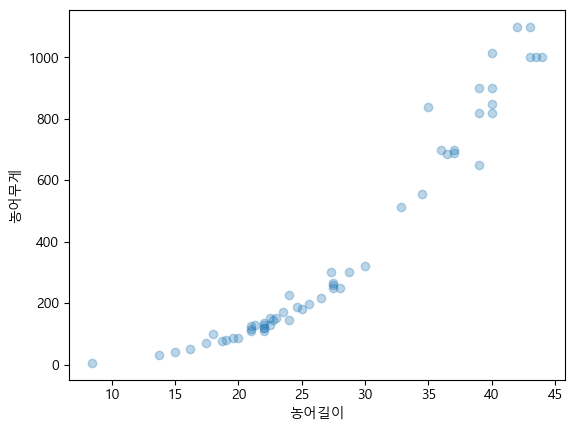

In [158]:
#k최근접이웃회귀분석: 거리기반 지도학습 분류모델

from sklearn.neighbors import KNeighborsRegressor
import numpy as np
import matplotlib.pyplot as plt
농어길이 = np.array([8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0, 21.0,
       21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5, 22.5, 22.7,
       23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5, 27.3, 27.5, 27.5,
       27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0, 36.5, 36.0, 37.0, 37.0,
       39.0, 39.0, 39.0, 40.0, 40.0, 40.0, 40.0, 42.0, 43.0, 43.0, 43.5,
       44.0])
농어무게 = np.array([5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 110.0,
       115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 130.0,
       150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 197.0,
       218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 514.0,
       556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 820.0,
       850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 1000.0,
       1000.0])

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.scatter(농어길이, 농어무게, alpha=0.3)
plt.xlabel('농어길이')
plt.ylabel('농어무게')
plt.show()

In [159]:
from sklearn.model_selection import train_test_split
훈련입력, 테스트입력, 훈련타깃, 테스트타깃 = train_test_split(농어길이, 농어무게, random_state=42)
print(훈련입력.shape, 훈련타깃.shape, 테스트입력.shape, 테스트타깃.shape)

from sklearn.neighbors import KNeighborsRegressor
knr = KNeighborsRegressor(n_neighbors=3)
knr.fit(훈련입력, 훈련타깃)
print(knr.score(훈련입력, 훈련타깃))
print(knr.score(테스트입력, 테스트타깃))

from sklearn.metrics import mean_absolute_error
예측결과 = knr.predict(테스트입력)
mean_absolute_error(테스트타깃, 예측결과)


(42,) (42,) (14,) (14,)


ValueError: Expected 2D array, got 1D array instead:
array=[19.6 22.  18.7 17.4 36.  25.  40.  39.  43.  22.  20.  22.  24.  27.5
 43.  40.  24.  21.  27.5 40.  32.8 26.5 36.5 13.7 22.7 15.  37.  35.
 28.7 23.5 39.  21.  23.  22.  44.  22.5 19.  37.  22.  25.6 42.  34.5].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

In [ ]:
x = np.arange(1, 46).reshape(-1, 1)
k_list = [1, 4, 8, 16, 32]
knr2 = KNeighborsRegressor()
for k in k_list:
    knr2.n_neighbors = k
    knr2.fit(훈련입력, 훈련타깃)
    predict_list = knr2.predict(x)
    
    plt.scatter(훈련입력, 훈련타깃, alpha=0.3)
    plt.plot(x, predict_list, c='red')
    plt.title(f'n_neighbors = {k}')
    
    plt.savefig('최근접 k별 그래프 복잡도')
    plt.show()
    

0.9398463339976041
0.824750312331356
[1241.83860323]


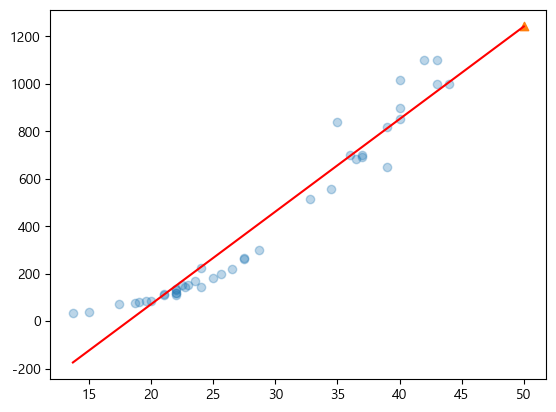

In [ ]:
#선형회귀분석 linear regressor
# idx = knr.kneighbors([[50]], return_distance=False)

# plt.scatter(훈련입력, 훈련타깃, alpha=0.3)
# plt.scatter(훈련입력[idx], 훈련타깃[idx], c='orange', marker='*')
# plt.scatter(60, knr.predict([[60]]), marker='^', c='red')
# plt.show()

from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(훈련입력, 훈련타깃)
print(lr.score(훈련입력, 훈련타깃))
print(lr.score(테스트입력, 테스트타깃))
print(lr.predict([[50]]))

idx = np.argsort(훈련입력[:, 0])

import matplotlib.pyplot as plt
plt.rcParams['font.family']='Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.scatter(훈련입력, 훈련타깃, alpha=0.3)
plt.scatter(50, lr.predict([[50]]), marker='^')
plt.plot(np.concatenate((훈련입력[idx, 0].reshape(-1, ), np.arange(45, 51).reshape(-1, ))), np.concatenate((훈련입력[idx, 0].reshape(-1, ), np.arange(45, 51)))*lr.coef_ + lr.intercept_, c='red')
plt.show()



(42, 2) (14, 2)
0.9706807451768623
0.9775935108325122
[  1.01433211 -21.55792498] 116.0502107827827
[1573.98423528]
(48, 2) (48,)


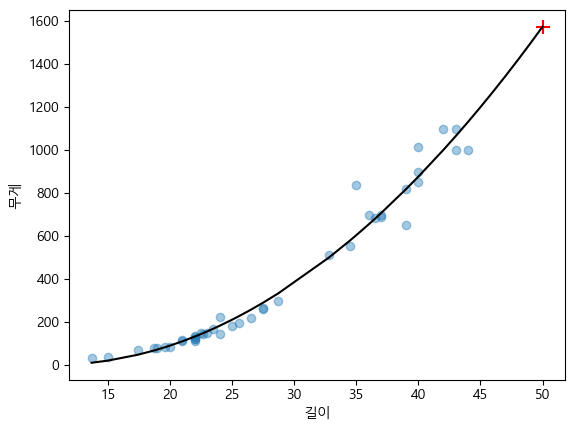

In [170]:
훈련입력2 = np.column_stack((훈련입력**2, 훈련입력))
테스트입력2 = np.column_stack((테스트입력**2, 테스트입력))
print(훈련입력2.shape, 테스트입력2.shape)

lr2 = LinearRegression()
lr2.fit(훈련입력2, 훈련타깃)
print(lr2.score(훈련입력2, 훈련타깃))
print(lr2.score(테스트입력2, 테스트타깃))
print(lr2.coef_, lr2.intercept_)
print(lr2.predict([[50**2, 50]]))

#산점도 및 선그래프 그리기
add_array = np.column_stack((np.arange(45, 51)**2, np.arange(45, 51))).reshape(-1, 2)
x_idx = np.argsort(훈련입력2[:, 1])
x = np.concatenate((훈련입력2[x_idx], add_array))
y = lr2.coef_[0]*x[:, 0] + lr2.coef_[1]*x[:, 1] + lr2.intercept_
print(x.shape, y.shape)
plt.scatter(훈련입력, 훈련타깃, alpha=0.4)
plt.scatter(50, lr2.predict([[50**2, 50]]), marker='+', s=100, c='red')
plt.plot(x[:, 1], y, c='black')
plt.xlabel('길이')
plt.ylabel('무게')
plt.show()



['length' ' height' ' width' 'length^2' 'length  height' 'length  width'
 ' height^2' ' height  width' ' width^2']
(42, 9)
(14, 9)
0.9920284561163715
0.9752659575171383


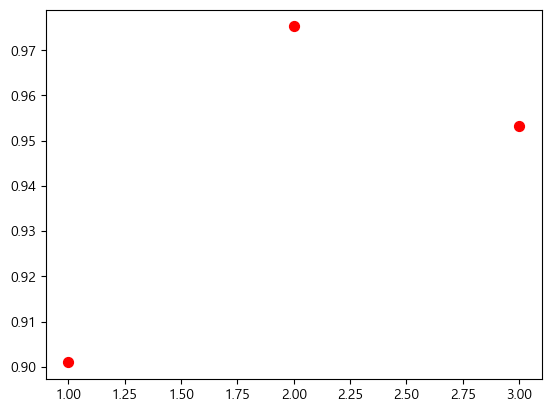

In [217]:
import pandas as pd

perch_full = pd.read_csv(r'https://raw.githubusercontent.com/rickiepark/hg-mldl/master/perch_full.csv')
perch_weight = np.array([5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 110.0,
       115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 130.0,
       150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 197.0,
       218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 514.0,
       556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 820.0,
       850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 1000.0,
       1000.0])

from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = train_test_split(perch_full, perch_weight)

data = [(x, x*y) for x in range(10) for y in range(20)]
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(include_bias=False, degree=3)
poly.fit(data)
poly_data = poly.transform(data)
poly_data.shape

poly = PolynomialFeatures(include_bias=False)
poly.fit(train_input)
train_poly_input = poly.transform(train_input)
print(poly.get_feature_names_out())
print(train_poly_input.shape)
test_poly_input = poly.transform(test_input)
print(test_poly_input.shape)

#다중회귀 훈련
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(train_poly_input, train_target)
print(lr.score(train_poly_input, train_target))
print(lr.score(test_poly_input, test_target))

plt.rcParams['axes.unicode_minus']=False
for n in range(1, 4):
       #특성 변환
       poly = PolynomialFeatures(degree=n)
       poly.fit(train_input)
       train_poly_input = poly.transform(train_input)
       test_poly_input = poly.transform(test_input)
       
       #회귀식
       lr = LinearRegression()
       lr.fit(train_poly_input, train_target)
       score = lr.score(test_poly_input, test_target)
       
       #그래프 그리기
       plt.scatter(n, score, s=50, c='red')
plt.show()
       


,length,height,width
24,24.0,7.29,3.72
27,25.0,6.44,3.68
25,24.0,6.38,3.82
35,28.7,7.59,4.64
12,21.0,5.69,3.67
30,27.3,8.32,5.14
54,43.5,12.60,8.14
15,22.0,5.64,3.52
19,22.5,5.86,3.62
40,36.5,10.88,6.86
